# Univariate and Bivariate Analysis of Application (loan) Data
- table - application_train.csv
---

__Loan info__:
- `SK_ID_CURR` - ID of loan in our sample
- `TARGET` - Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)
- `NAME_CONTRACT_TYPE` - Identification if loan is cash or revolving
- `AMT_CREDIT` - Credit amount of the loan
- `AMT_ANNUITY` - Loan annuity
- `AMT_GOODS_PRICE` - For consumer loans it is the price of the goods for which the loan is given

## 0. Libraries and Data

In [44]:
import pandas as pd
import numpy as np

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / 'src'

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from eda_module import (
    plot_quantitative_distribution, plot_binary_distribution, 
    plot_binary_vs_binary, plot_quantitative_vs_binary, plot_categorical_distribution,
    plot_categorical_vs_binary
)

from preprocess_module import (
    bin_quantitative_var
)

In [45]:
app_df = pd.read_csv(r"..\data\raw\application_train.csv")
print(f"Shape of app_df: {app_df.shape}")
app_df.head(10)

Shape of app_df: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
loan_cols = ['SK_ID_CURR','TARGET', 'NAME_CONTRACT_TYPE','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE']
app_df[loan_cols].head(10)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE
0,100002,1,Cash loans,406597.5,24700.5,351000.0
1,100003,0,Cash loans,1293502.5,35698.5,1129500.0
2,100004,0,Revolving loans,135000.0,6750.0,135000.0
3,100006,0,Cash loans,312682.5,29686.5,297000.0
4,100007,0,Cash loans,513000.0,21865.5,513000.0
5,100008,0,Cash loans,490495.5,27517.5,454500.0
6,100009,0,Cash loans,1560726.0,41301.0,1395000.0
7,100010,0,Cash loans,1530000.0,42075.0,1530000.0
8,100011,0,Cash loans,1019610.0,33826.5,913500.0
9,100012,0,Revolving loans,405000.0,20250.0,405000.0


## 1. SK_ID_CURR
This is ID of loand in our sample. It won't be used in modeling phase, it may be helpful in joining tables and identifying duplicate observationst though.

In [47]:
if app_df['SK_ID_CURR'].nunique() == app_df.shape[0]:
    print("There aren't any duplicate observations")
else:
    print("There are some duplicate observations")

There aren't any duplicate observations


## 2. Target

This is our dependent variable.

In [48]:
app_df['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

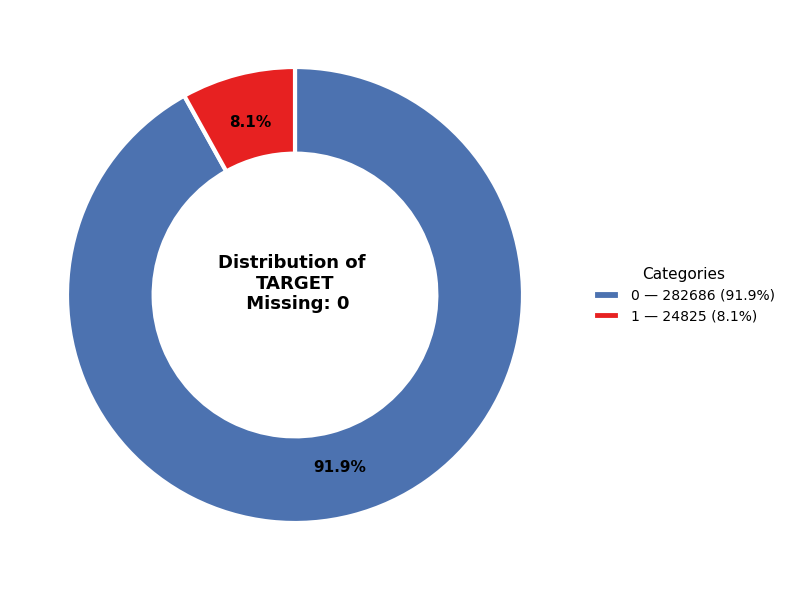

In [49]:
plot_binary_distribution(df=app_df, binary_var='TARGET')

`TARGET` is dominated by category `0` (`non-default`), which has to be accounted for in the modeling phase. <br> Moreover there are no `NAN` values for our dependent variable.

## 4. NAME_CONTRACT_TYPE

Identification if loan is cash or revolving

In [50]:
app_df['NAME_CONTRACT_TYPE'].value_counts()

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

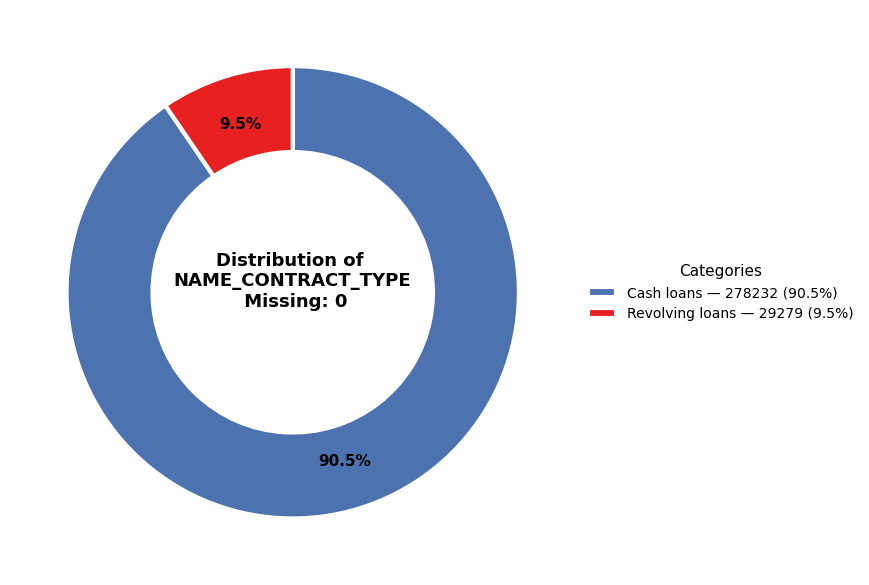

In [51]:
plot_binary_distribution(df=app_df, binary_var='NAME_CONTRACT_TYPE')

`NAME_CONTRACT_TYPE` is dominated by `Cash loans` - 90.5% obs belong to this category. There are no missing values.

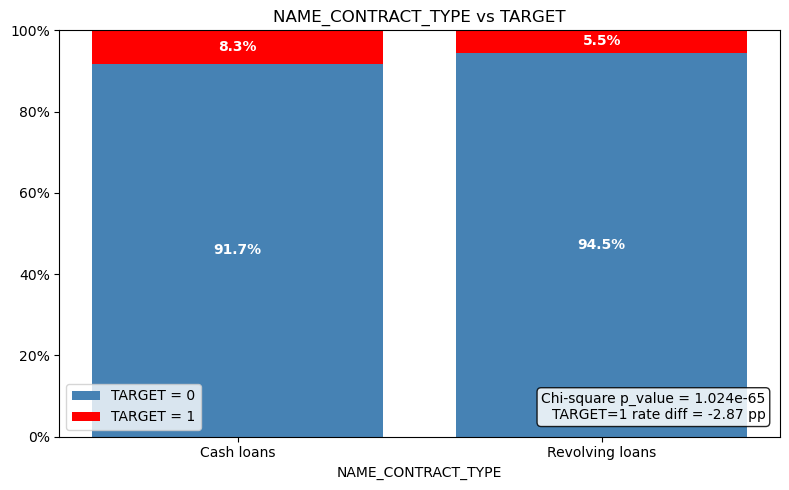

In [52]:
plot_binary_vs_binary(df=app_df, binary_var='NAME_CONTRACT_TYPE', target_var='TARGET')

There is a sifnificant difference in risk ratios.

## 5. AMT_CREDIT

In [53]:
app_df['AMT_CREDIT'].describe()

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

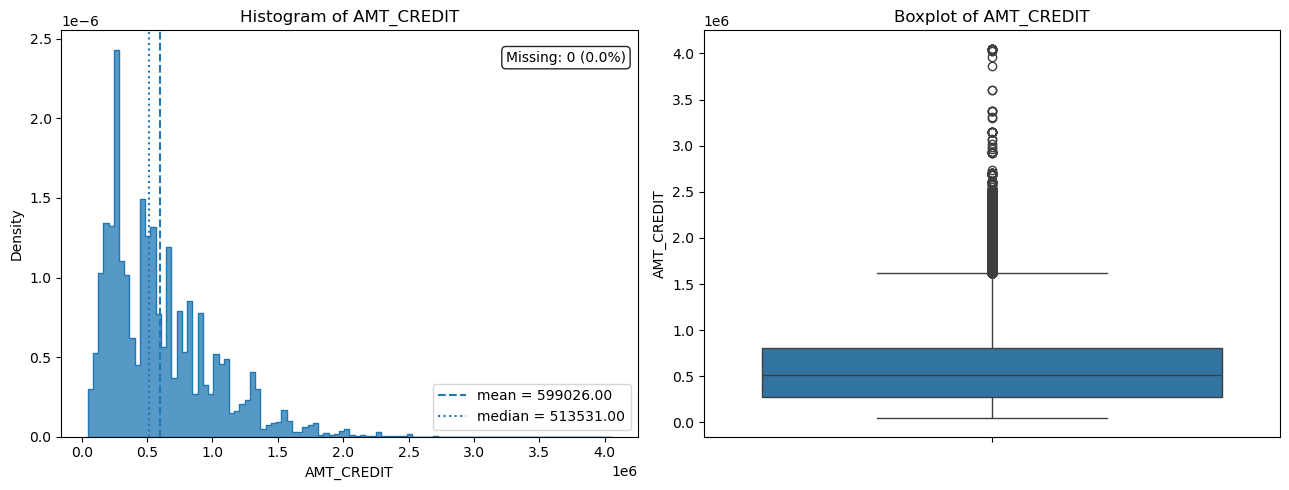

In [54]:
plot_quantitative_distribution(df=app_df, quant_var='AMT_CREDIT', hist_bins=100)

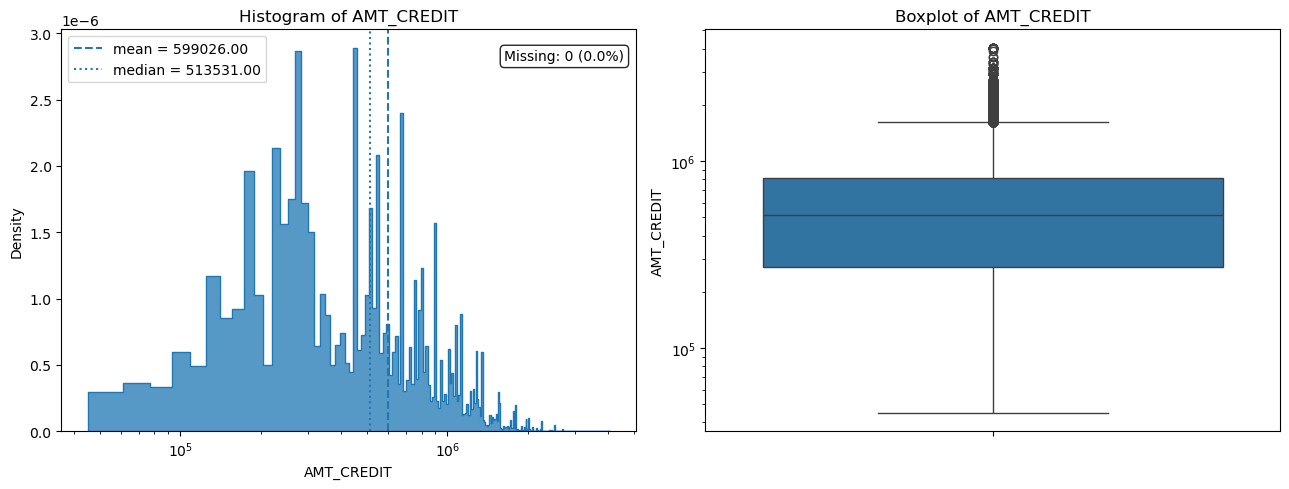

In [55]:
plot_quantitative_distribution(df=app_df, quant_var='AMT_CREDIT', log_scale=True)

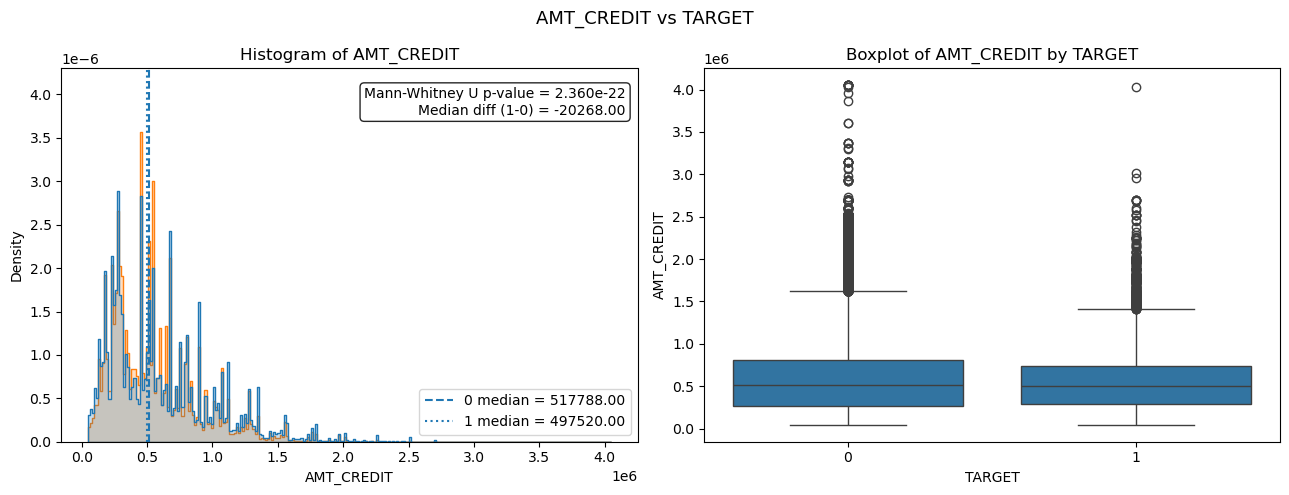

In [56]:
plot_quantitative_vs_binary(df=app_df, quant_var='AMT_CREDIT', target_var='TARGET')

Surprisingly loans which defaulted had lower `AMT_CREDIT`, which tells us that probably more risky customers where given less credit amount. The difference is statistically significant.

In [57]:
amt_credit_binned, binned_df, amt_quantiles_summary = bin_quantitative_var(
    df = app_df,
    quant_var='AMT_CREDIT',
    quantiles_bins=True,
    target_var='TARGET',
    return_binned_quantiles=True,
    return_summary=True,
    return_df=True
)

amt_quantiles_summary

,feature,binned_column,binning_type,bin,count,share,n_target_1,n_target_0,target_rate
0,AMT_CREDIT,AMT_CREDIT_binned_quantiles,quantiles,Q1,64925,0.211131,4699,60226,0.072376
1,AMT_CREDIT,AMT_CREDIT_binned_quantiles,quantiles,Q2,58098,0.188930,5329,52769,0.091724
2,AMT_CREDIT,AMT_CREDIT_binned_quantiles,quantiles,Q3,61552,0.200162,6189,55363,0.100549
3,AMT_CREDIT,AMT_CREDIT_binned_quantiles,quantiles,Q4,64024,0.208201,5029,58995,0.078549
4,AMT_CREDIT,AMT_CREDIT_binned_quantiles,quantiles,Q5,58912,0.191577,3579,55333,0.060752


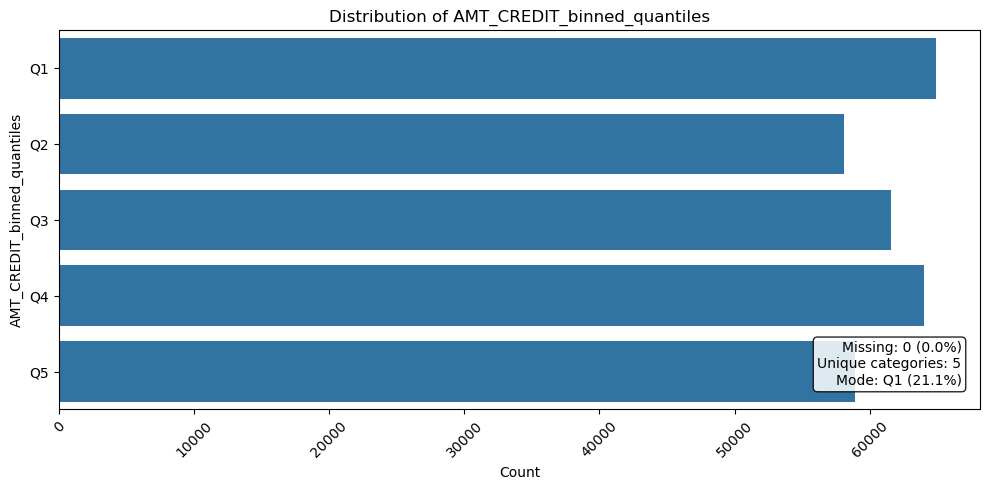

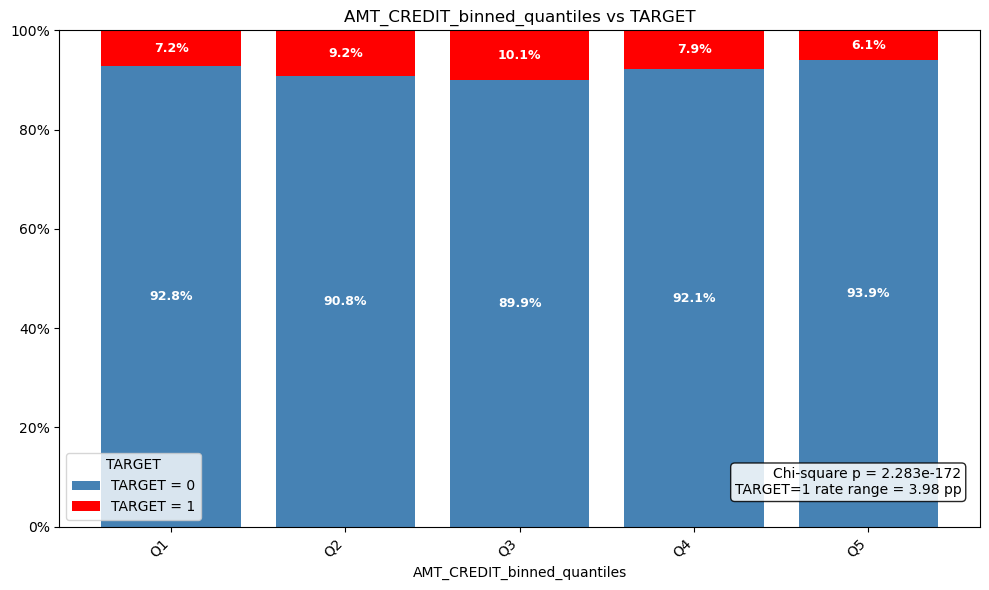

In [58]:
plot_categorical_distribution(df=binned_df, cat_var='AMT_CREDIT_binned_quantiles', respect_category_order=True)
plot_categorical_vs_binary(df=binned_df, cat_var='AMT_CREDIT_binned_quantiles', target_var='TARGET', respect_category_order=True)

It looks like the relation bewteen `AMT_CREDIT` and `TARGET` is not linear.

## 6. AMT_ANNUITY 
Loan annuity

In [59]:
app_df['AMT_ANNUITY'].describe()

count    307499.000000
mean      27108.573909
std       14493.737315
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64

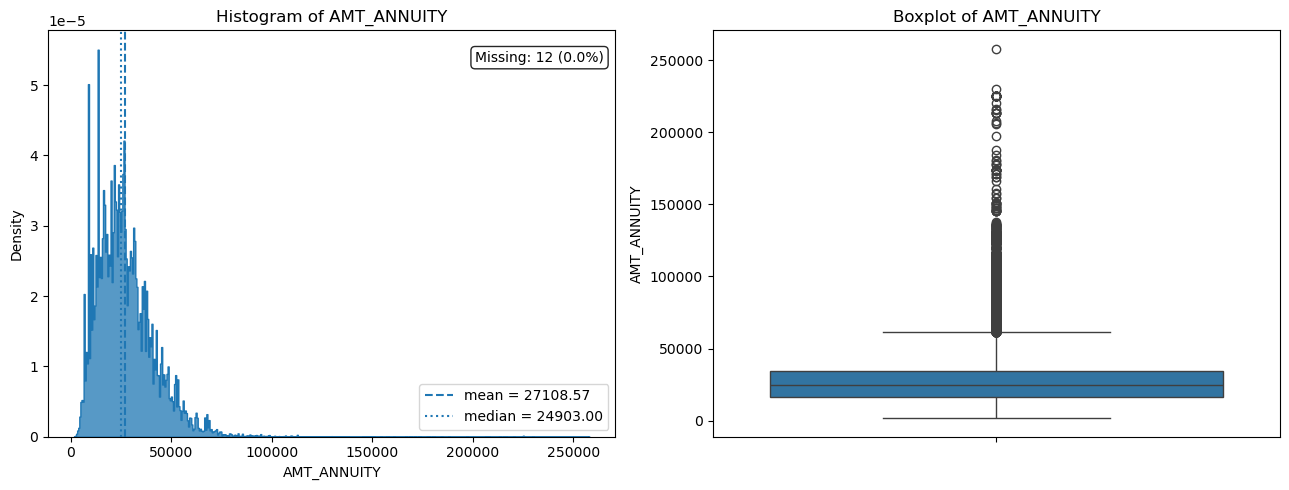

TypeError: plot_quantitative_vs_binary() got an unexpected keyword argument 'binary_var'

In [60]:
plot_quantitative_distribution(df=app_df, quant_var='AMT_ANNUITY')
plot_quantitative_vs_binary(df=app_df, quant_var='AMT_ANNUITY', binary_var='TARGET')

In [ ]:
binned_df, amt_annuity_quantiles_summary = bin_quantitative_var(
    df = binned_df,
    quant_var='AMT_ANNUITY',
    quantiles_bins=True,
    target_var='TARGET',
    return_binned_quantiles=False,
    return_summary=True,
    return_df=True
)

amt_annuity_quantiles_summary

,feature,binned_column,binning_type,bin,count,share,n_target_1,n_target_0,target_rate
0,AMT_ANNUITY,AMT_ANNUITY_binned_quantiles,quantiles,Q1,61507,0.200016,4274,57233,0.069488
1,AMT_ANNUITY,AMT_ANNUITY_binned_quantiles,quantiles,Q2,61494,0.199973,5278,56216,0.085830
2,AMT_ANNUITY,AMT_ANNUITY_binned_quantiles,quantiles,Q3,61562,0.200194,5412,56150,0.087911
3,AMT_ANNUITY,AMT_ANNUITY_binned_quantiles,quantiles,Q4,61452,0.199837,5739,55713,0.093390
4,AMT_ANNUITY,AMT_ANNUITY_binned_quantiles,quantiles,Q5,61484,0.199941,4122,57362,0.067042
5,AMT_ANNUITY,AMT_ANNUITY_binned_quantiles,quantiles,NaN,12,0.000039,0,12,0.000000


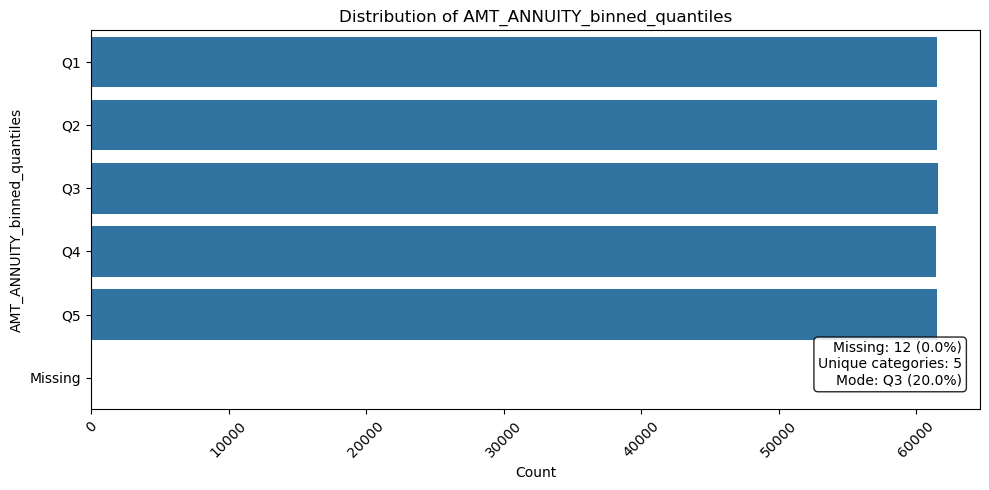

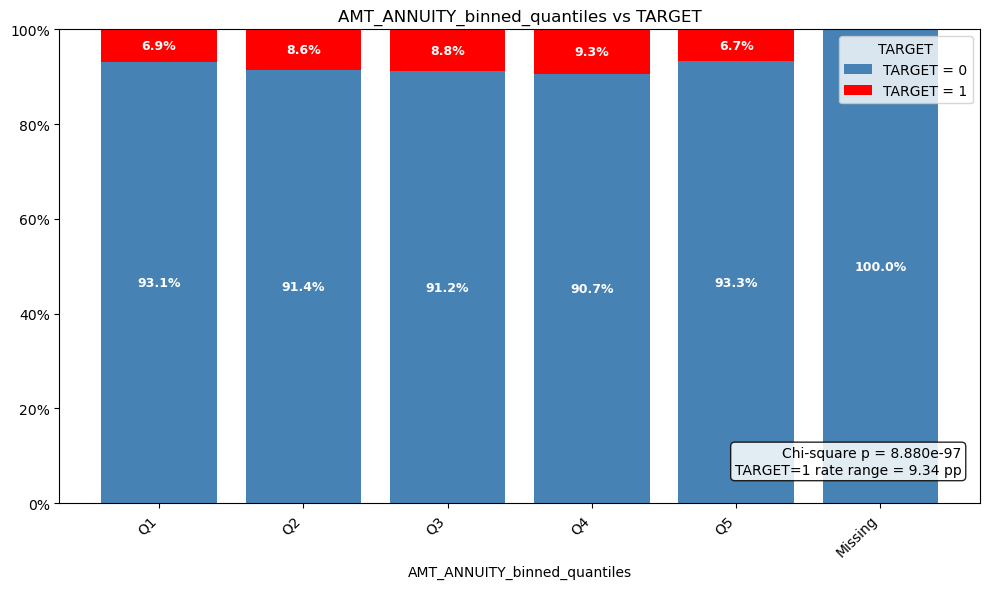

In [ ]:
plot_categorical_distribution(df=binned_df, cat_var='AMT_ANNUITY_binned_quantiles', respect_category_order=True)
plot_categorical_vs_binary(df=binned_df, cat_var='AMT_ANNUITY_binned_quantiles', target_var='TARGET', respect_category_order=True)

The difference of `AMT_ANNUITY` between values of `TARGET` is not statistically significant but it is for `AMT_ANNUITY_binned_quantiles`.

## 7. AMT_GOODS_PRICE

In [ ]:
app_df['AMT_GOODS_PRICE'].describe()

count    3.072330e+05
mean     5.383962e+05
std      3.694465e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64

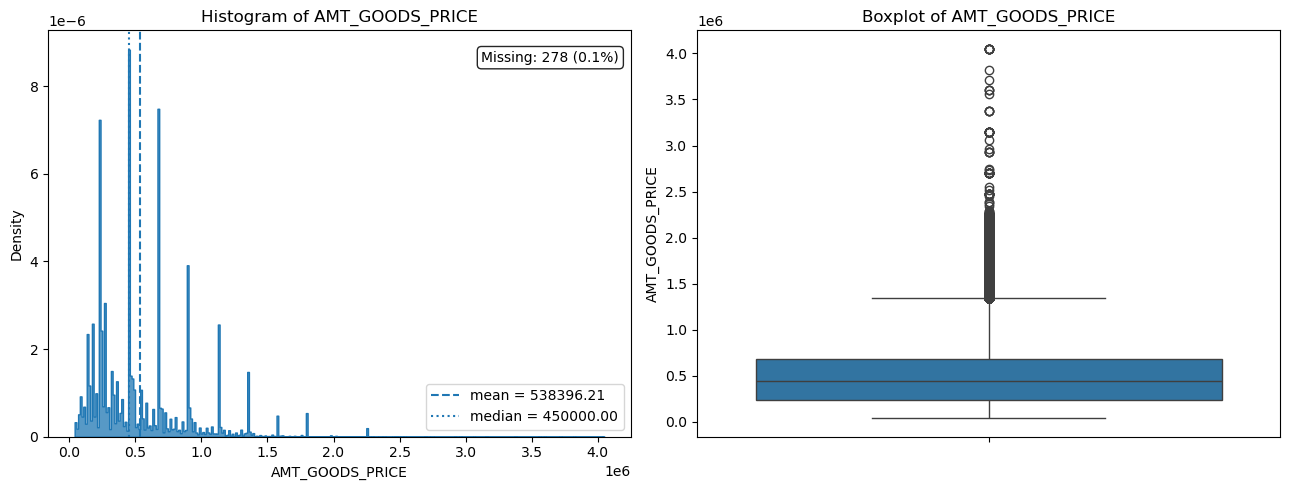

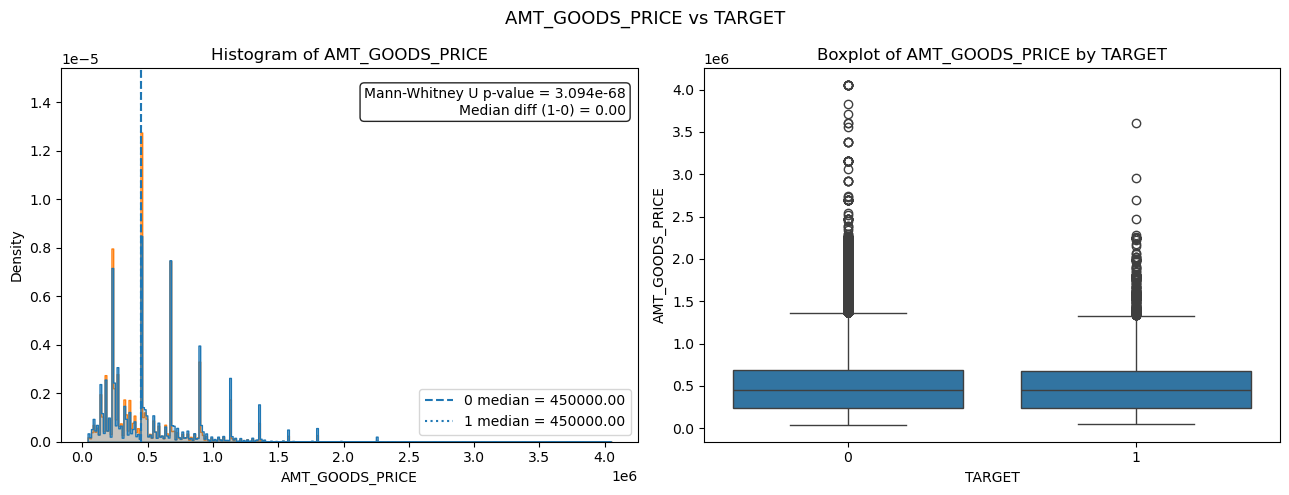

In [ ]:
plot_quantitative_distribution(df=app_df, target_var='AMT_GOODS_PRICE')
plot_quantitative_vs_binary(df=app_df, target_var='AMT_GOODS_PRICE', binary_var='TARGET')

The difference in ditribution of `AMT_GOODS_PRICE` is not statistically significant (medians are equal).

In [ ]:
binned_df, amt_goods_quantiles_summary = bin_quantitative_var(
    df = binned_df,
    quant_var='AMT_GOODS_PRICE',
    quantiles_bins=True,
    target_var='TARGET',
    return_binned_quantiles=False,
    return_summary=True,
    return_df=True
)

amt_goods_quantiles_summary

,feature,binned_column,binning_type,bin,count,share,n_target_1,n_target_0,target_rate
0,AMT_GOODS_PRICE,AMT_GOODS_PRICE_binned_quantiles,quantiles,Q1,71454,0.232362,5725,65729,0.080121
1,AMT_GOODS_PRICE,AMT_GOODS_PRICE_binned_quantiles,quantiles,Q2,51473,0.167386,4526,46947,0.087930
2,AMT_GOODS_PRICE,AMT_GOODS_PRICE_binned_quantiles,quantiles,Q3,61527,0.200081,6384,55143,0.103759
3,AMT_GOODS_PRICE,AMT_GOODS_PRICE_binned_quantiles,quantiles,Q4,61349,0.199502,4650,56699,0.075796
4,AMT_GOODS_PRICE,AMT_GOODS_PRICE_binned_quantiles,quantiles,Q5,61430,0.199765,3519,57911,0.057285
5,AMT_GOODS_PRICE,AMT_GOODS_PRICE_binned_quantiles,quantiles,NaN,278,0.000904,21,257,0.075540


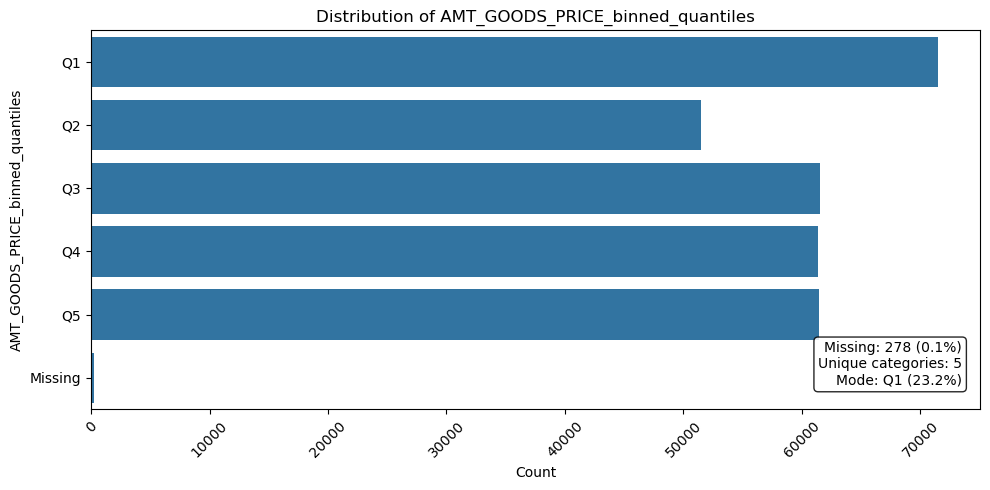

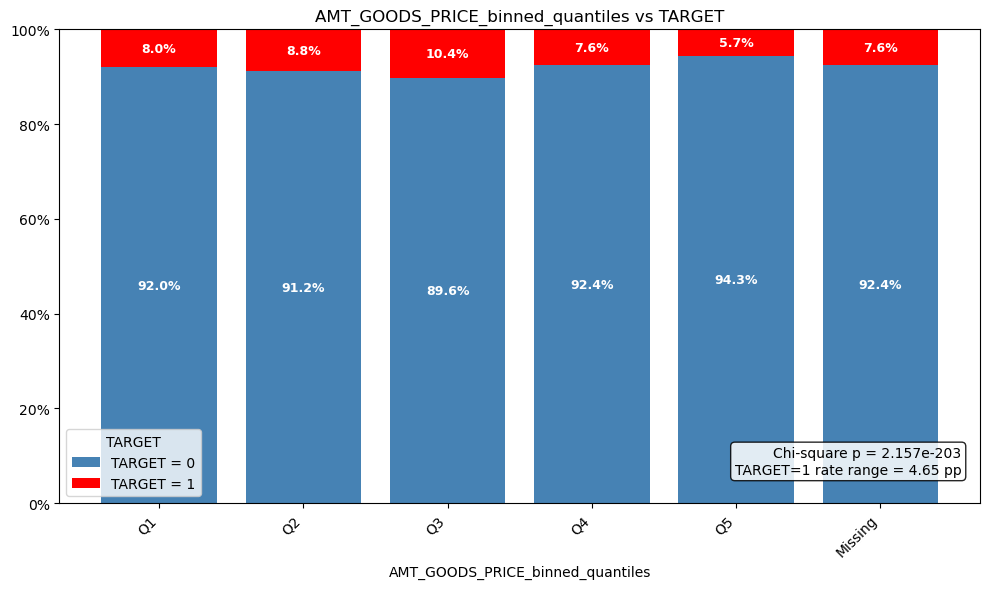

In [ ]:
plot_categorical_distribution(df=binned_df, cat_var='AMT_GOODS_PRICE_binned_quantiles', respect_category_order=True)
plot_categorical_vs_binary(df=binned_df, cat_var='AMT_GOODS_PRICE_binned_quantiles', target_var='TARGET', respect_category_order=True)

Binned version of `AMT_ANNUITY` seems to be a good candidate for a predictior.

## 8. Loan Info Summary
Variables that can be used as preditcotrs:
- NAME_CONTRACT_TYPE
- AMT_CREDIT
- AMT_CREDIT_binned_quantiles
- AMT_ANNUITY_binned_quantiles
- AMT_GOODS_PRICE_binned_quantiles
